# 253. Meeting Rooms II
https://leetcode.com/problems/meeting-rooms-ii/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Min Heap | O(n log n) | O(n) | Sort by start, use heap to track end times |
| **Chronological Ordering** | **O(n log n)** | **O(n)** | **Separate starts/ends, sweep line** |

## Methodology

We use the **sweep line** (chronological ordering) approach. Separate all start times and end times into two sorted arrays. Use two pointers to sweep through events: when a start comes before an end, we need one more room; when an end comes first, a room is freed. Track the maximum concurrent meetings.

## Solutions

### C#

In [ ]:
// 253. Meeting Rooms II
// Time: O(n log n) | Space: O(n)
public class Solution {
    public int MinMeetingRooms(int[][] intervals) {
        int n = intervals.Length;
        int[] starts = new int[n];
        int[] ends = new int[n];
        
        for (int i = 0; i < n; i++) {
            starts[i] = intervals[i][0];
            ends[i] = intervals[i][1];
        }
        
        Array.Sort(starts);
        Array.Sort(ends);
        
        int rooms = 0, endPtr = 0;
        for (int i = 0; i < n; i++) {
            if (starts[i] < ends[endPtr])
                rooms++;
            else
                endPtr++;
        }
        return rooms;
    }
}

### Python

In [ ]:
# 253. Meeting Rooms II
# Time: O(n log n) | Space: O(n)
class Solution:
    def minMeetingRooms(self, intervals: list[list[int]]) -> int:
        starts = sorted(i[0] for i in intervals)
        ends = sorted(i[1] for i in intervals)
        
        rooms = 0
        end_ptr = 0
        for start in starts:
            if start < ends[end_ptr]:
                rooms += 1
            else:
                end_ptr += 1
        return rooms

### Go

In [ ]:
// 253. Meeting Rooms II
// Time: O(n log n) | Space: O(n)
import "sort"

func minMeetingRooms(intervals [][]int) int {
    n := len(intervals)
    starts := make([]int, n)
    ends := make([]int, n)
    
    for i, interval := range intervals {
        starts[i] = interval[0]
        ends[i] = interval[1]
    }
    
    sort.Ints(starts)
    sort.Ints(ends)
    
    rooms, endPtr := 0, 0
    for i := 0; i < n; i++ {
        if starts[i] < ends[endPtr] {
            rooms++
        } else {
            endPtr++
        }
    }
    return rooms
}

### Rust

In [ ]:
// 253. Meeting Rooms II
// Time: O(n log n) | Space: O(n)
impl Solution {
    pub fn min_meeting_rooms(intervals: Vec<Vec<i32>>) -> i32 {
        let mut starts: Vec<i32> = intervals.iter().map(|i| i[0]).collect();
        let mut ends: Vec<i32> = intervals.iter().map(|i| i[1]).collect();
        
        starts.sort();
        ends.sort();
        
        let mut rooms = 0;
        let mut end_ptr = 0;
        for &start in &starts {
            if start < ends[end_ptr] {
                rooms += 1;
            } else {
                end_ptr += 1;
            }
        }
        rooms
    }
}

## Example Scenarios

1. **Common Case** — Three meetings, two overlap  
   **Input:** `intervals = [[0,30],[5,10],[15,20]]`  
   Sort starts: $0, 5, 15$. Sort ends: $10, 20, 30$. At time 5, meetings $[0,30]$ and $[5,10]$ overlap. Max concurrent = $2$. At time 15, $[5,10]$ ended so only $[0,30]$ and $[15,20]$ overlap. Answer = $2$.

2. **Slightly Complex** — All meetings overlap  
   **Input:** `intervals = [[1,10],[2,7],[3,19],[8,12],[10,20]]`  
   At time 3: meetings $[1,10], [2,7], [3,19]$ all active — 3 rooms needed. At time 8: $[2,7]$ ended, $[8,12]$ starts — back to 3. Peak concurrent = $3$. Track with two-pointer sweep over sorted start/end arrays.

3. **Edge Case: Time Factor** — $n$ meetings with staggered overlaps  
   **Input:** `intervals = [[0,100],[1,100],[2,100],...,[n-1,100]]` ($n = 10^4$)  
   Every meeting overlaps with every other. Sorting is $O(n \log n)$. The sweep increments the room counter $n$ times before any end event. All $n$ rooms needed simultaneously.

4. **Edge Case: Space Factor** — All meetings are sequential (no overlap)  
   **Input:** `intervals = [[0,1],[1,2],[2,3],...,[9999,10000]]`  
   Sorted starts and ends arrays each have $n$ elements ($O(n)$ space). But each meeting starts as the previous ends, so the concurrent count never exceeds $1$. Answer = $1$.

5. **Almost-Impossible but Plausible** — Two meetings with identical times  
   **Input:** `intervals = [[0, 2147483647],[0, 2147483647]]`  
   Both start and end at the same extreme times. They fully overlap, requiring $2$ rooms. Tests that equal start times both count and that large values near $2^{31}-1$ don't cause overflow.


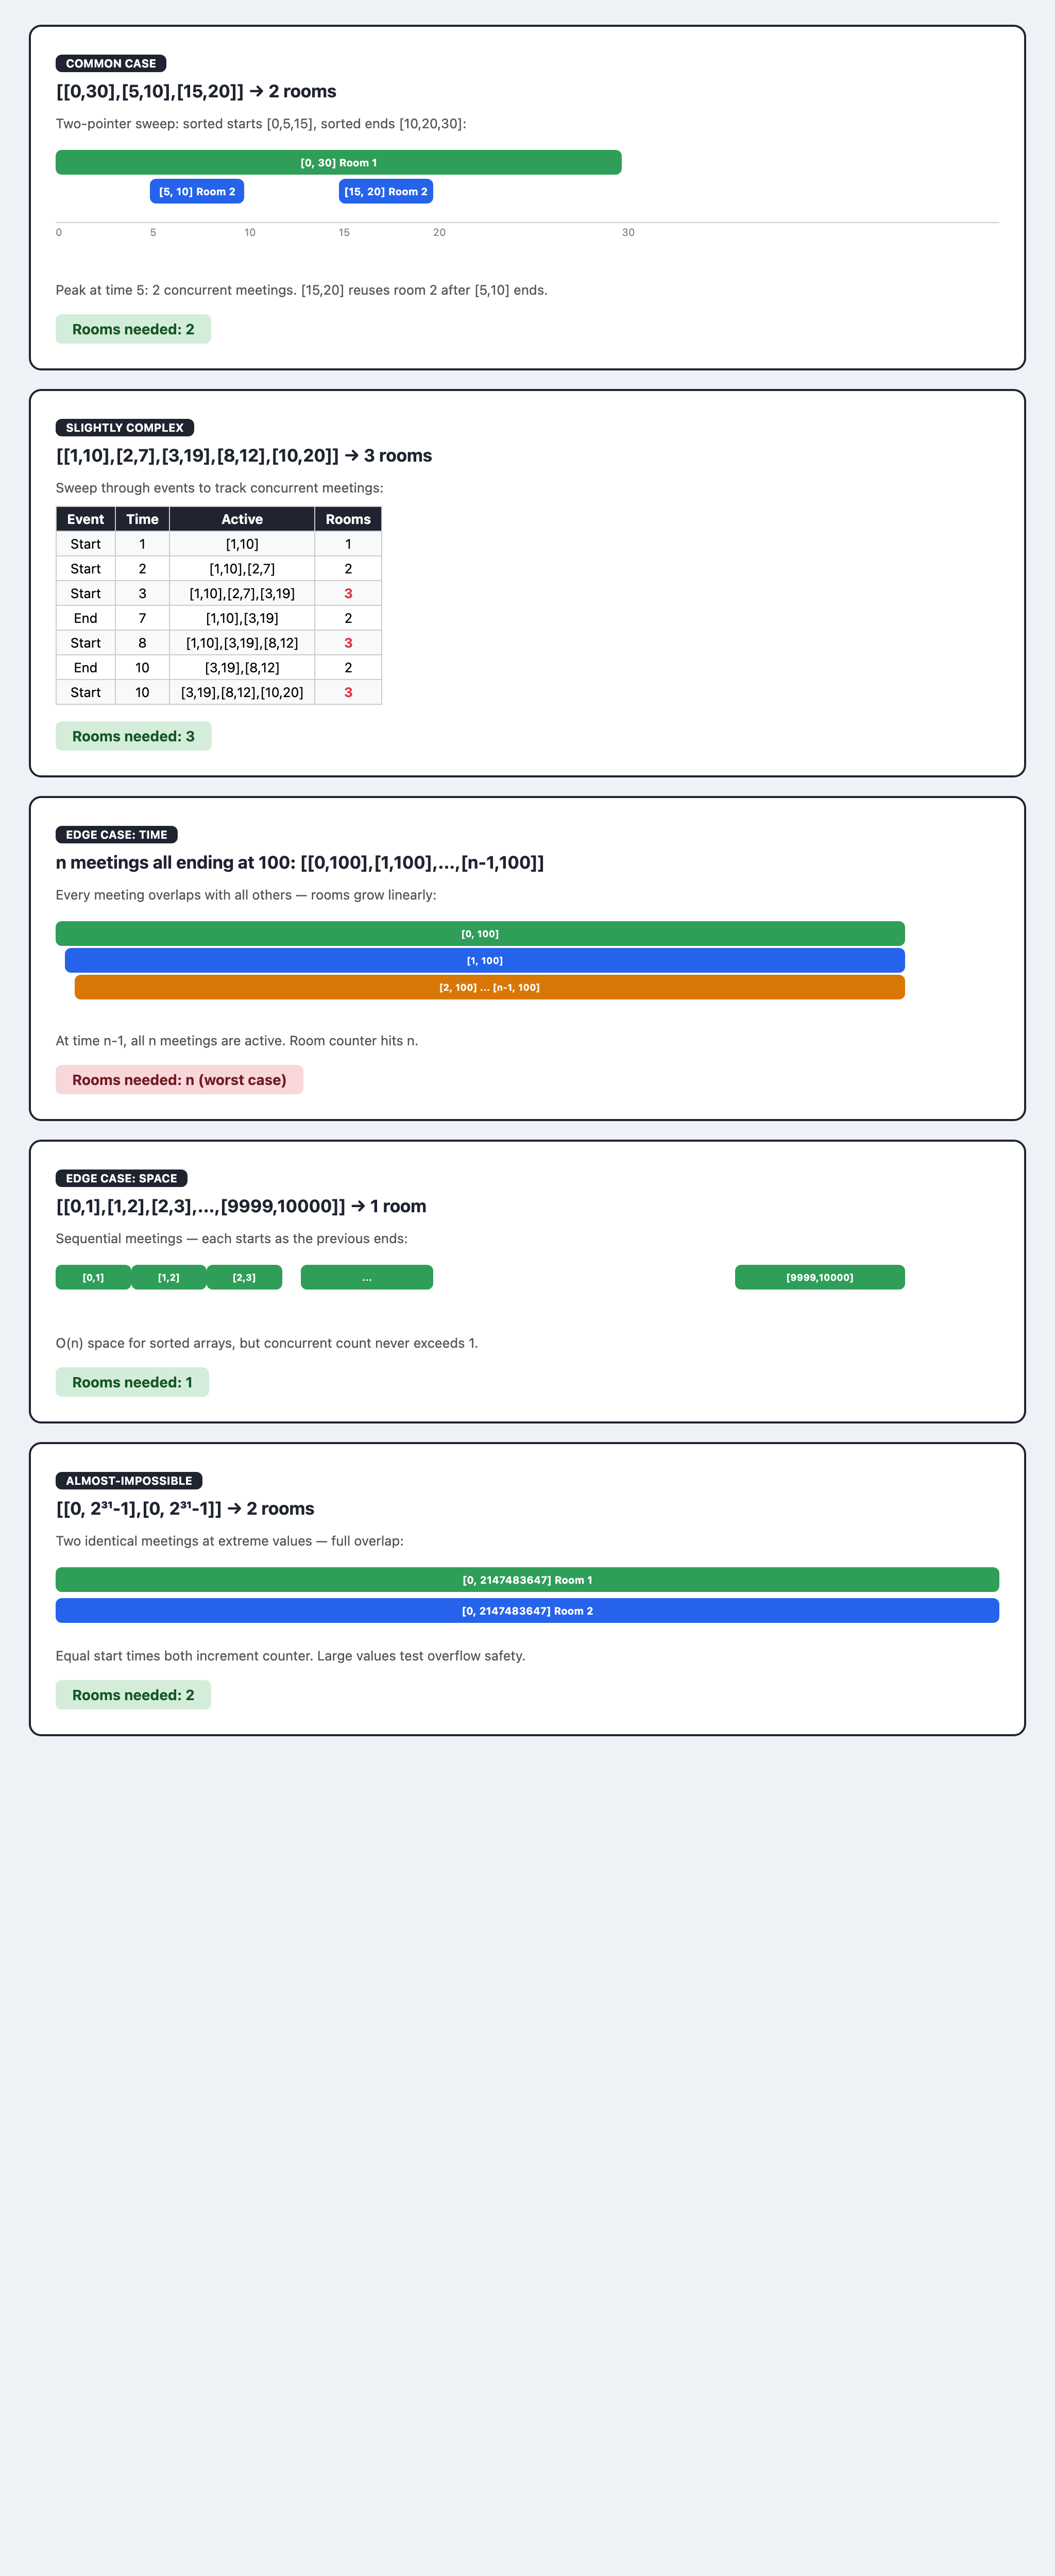